# ICU Risk Scoring Engine — MIMIC-IV
> **Scores**: qSOFA | SOFA | APACHE II | SAPS3  
> **Output**: Sepsis risk · Mortality risk · Organ dysfunction · Patient prioritisation  
> **Inputs**: `icu_hourly_features_24h.parquet` + `icu_static_features.parquet`


## Step 1 — Environment Setup

In [1]:
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

# ── Paths
OUT_BASE   = Path('/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet')
HOURLY_PATH = OUT_BASE / 'icu_hourly_features_24h.parquet'
STATIC_PATH = OUT_BASE / 'icu_static_features.parquet'
SCORES_PATH = OUT_BASE / 'icu_risk_scores.parquet'

# ── Plot theme
DARK_BG    = '#0F172A'
CARD_BG    = '#1E293B'
TEXT_COLOR = '#F1F5F9'
GRID_COLOR = '#334155'
PAL = {
    'green':  '#16A34A',
    'yellow': '#CA8A04',
    'orange': '#EA580C',
    'red':    '#DC2626',
    'blue':   '#2563EB',
    'purple': '#7C3AED',
    'teal':   '#0891B2',
}
RISK_COLORS = [PAL['green'], PAL['yellow'], PAL['orange'], PAL['red']]

plt.rcParams.update({
    'figure.facecolor': DARK_BG, 'axes.facecolor': CARD_BG,
    'axes.edgecolor': GRID_COLOR, 'axes.labelcolor': TEXT_COLOR,
    'axes.titlecolor': TEXT_COLOR, 'xtick.color': TEXT_COLOR,
    'ytick.color': TEXT_COLOR, 'text.color': TEXT_COLOR,
    'grid.color': GRID_COLOR, 'grid.linewidth': 0.5,
    'axes.grid': True, 'axes.titlesize': 13, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
})
print('Environment ready.')


Mounted at /content/drive
Environment ready.


## Step 2 — Load Parquet Files

In [2]:
hourly  = pd.read_parquet(HOURLY_PATH)
static  = pd.read_parquet(STATIC_PATH)

print(f'Hourly features : {hourly.shape}  | stays: {hourly["stay_id"].nunique():,}')
print(f'Static features : {static.shape}  | stays: {static["stay_id"].nunique():,}')
print(f'Hourly columns  : {list(hourly.columns)}')
print(f'Static columns  : {list(static.columns)}')


Hourly features : (2062047, 41)  | stays: 94,362
Static features : (94458, 10)  | stays: 94,458
Hourly columns  : ['stay_id', 'hour_ts', 'DBP', 'FiO2', 'GCS', 'HR', 'MAP', 'RR', 'SBP', 'SpO2', 'TEMP', 'vent', 'Bilirubin', 'Creatinine', 'Hematocrit', 'PaO2', 'Platelets', 'Potassium', 'Sodium', 'WBC', 'pH', 'DBP_missing', 'FiO2_missing', 'GCS_missing', 'HR_missing', 'MAP_missing', 'RR_missing', 'SBP_missing', 'SpO2_missing', 'TEMP_missing', 'Bilirubin_missing', 'Creatinine_missing', 'Hematocrit_missing', 'PaO2_missing', 'Platelets_missing', 'Potassium_missing', 'Sodium_missing', 'WBC_missing', 'pH_missing', 'PF_ratio', 'SF_ratio']
Static columns  : ['stay_id', 'subject_id', 'hadm_id', 'intime', 'outtime', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'urine_24h']


## Step 3 — Worst-Value Snapshot (24h Window)
> Clinical scores use the **worst** value observed in the scoring window, not the mean.


In [3]:
# For each stay, extract worst physiological values across the 24h window
# Worst = min for SpO2/MAP/GCS/pH/PaO2/Platelets/Urine
# Worst = max for Creatinine/Bilirubin/HR/RR/Temp/WBC

MIN_COLS = ['SpO2', 'MAP', 'GCS', 'pH', 'PaO2', 'Platelets', 'SBP', 'DBP']
MAX_COLS = ['Creatinine', 'Bilirubin', 'HR', 'RR', 'TEMP', 'WBC', 'Sodium', 'Potassium']

agg_dict = {}
for col in MIN_COLS:
    if col in hourly.columns:
        agg_dict[col] = 'min'
for col in MAX_COLS:
    if col in hourly.columns:
        agg_dict[col] = 'max'

# Also need: vent flag (any hour on vent), FiO2 (min for worst PF ratio)
if 'vent' in hourly.columns:
    agg_dict['vent'] = 'max'
if 'FiO2' in hourly.columns:
    agg_dict['FiO2'] = 'min'
if 'PF_ratio' in hourly.columns:
    agg_dict['PF_ratio'] = 'min'
if 'SF_ratio' in hourly.columns:
    agg_dict['SF_ratio'] = 'min'

worst = (
    hourly
    .groupby('stay_id')
    .agg(agg_dict)
    .reset_index()
)

# Merge static features
scores_df = worst.merge(
    static[['stay_id', 'subject_id', 'hadm_id', 'age_icu', 'gender',
            'is_elective', 'has_chronic', 'urine_24h']],
    on='stay_id', how='left'
)

print(f'Scoring cohort shape: {scores_df.shape}')
scores_df.head(3)


Scoring cohort shape: (94362, 28)


,stay_id,SpO2,MAP,GCS,pH,PaO2,Platelets,SBP,DBP,Creatinine,...,FiO2,PF_ratio,SF_ratio,subject_id,hadm_id,age_icu,gender,is_elective,has_chronic,urine_24h
0,30000153,92.0,71.0,4.0,7.30,215.0,162.0,109.0,55.0,1.1,...,0.21,1023.809509,93.000000,12466550,23998182,61,M,0,0,1235.0
1,30000213,96.0,69.0,3.5,7.37,56.0,226.0,116.0,47.0,3.7,...,0.21,266.666656,96.000000,13180007,27543152,66,M,0,1,3095.0
2,30000484,98.0,46.0,3.0,7.33,21.0,357.0,78.0,23.0,1.2,...,0.21,100.000000,466.666656,18421337,22413411,89,M,0,0,1210.0


## Step 4 — qSOFA Score (Rapid Sepsis Screening)
> **Range 0–3** | Score ≥ 2 = high suspicion for sepsis  
> Components: Altered mentation (GCS < 15) + Respiratory rate ≥ 22 + Systolic BP ≤ 100


In [4]:
def compute_qsofa(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['qsofa_gcs']  = ((df['GCS']  < 15)  .fillna(False)).astype(int)
    df['qsofa_rr']   = ((df['RR']   >= 22)  .fillna(False)).astype(int)
    df['qsofa_sbp']  = ((df['SBP']  <= 100) .fillna(False)).astype(int)
    df['qsofa_score'] = df[['qsofa_gcs', 'qsofa_rr', 'qsofa_sbp']].sum(axis=1)
    df['qsofa_risk']  = pd.cut(
        df['qsofa_score'],
        bins=[-1, 0, 1, 2, 3],
        labels=['Low', 'Moderate', 'High', 'Critical']
    )
    df['sepsis_screen_positive'] = (df['qsofa_score'] >= 2).astype(int)
    return df

scores_df = compute_qsofa(scores_df)
print('qSOFA distribution:')
print(scores_df['qsofa_score'].value_counts().sort_index())
print(f'\nSepsis screen positive (qSOFA >= 2): '
      f"{scores_df['sepsis_screen_positive'].sum():,} "
      f"({scores_df['sepsis_screen_positive'].mean()*100:.1f}%)")


qSOFA distribution:
qsofa_score
0      229
1     6016
2    34124
3    53993
Name: count, dtype: int64

Sepsis screen positive (qSOFA >= 2): 88,117 (93.4%)


## Step 5 — SOFA Score (Organ Failure Assessment)
> **Range 0–24** | Score ≥ 2 = organ dysfunction | Score ≥ 11 = >50% mortality  
> 6 organ systems: Respiratory · Coagulation · Liver · Cardiovascular · CNS · Renal


In [5]:
def sofa_respiratory(pf, sf, vent):
    """PaO2/FiO2 ratio (or SpO2/FiO2 if PaO2 unavailable)"""
    score = pd.Series(0, index=pf.index)
    # Use PF ratio if available, else SF ratio proxy
    ratio = pf.fillna(sf * 0.88)  # SF->PF approximation
    score = np.where(ratio.isna(),           0, score)
    score = np.where(ratio < 400,             1, score)
    score = np.where(ratio < 300,             2, score)
    score = np.where((ratio < 200) & (vent == 1), 3, score)
    score = np.where((ratio < 100) & (vent == 1), 4, score)
    return score

def sofa_coagulation(plt):
    score = np.zeros(len(plt))
    score = np.where(plt < 150, 1, score)
    score = np.where(plt < 100, 2, score)
    score = np.where(plt < 50,  3, score)
    score = np.where(plt < 20,  4, score)
    return score

def sofa_liver(bili):
    score = np.zeros(len(bili))
    score = np.where(bili >= 1.2,  1, score)
    score = np.where(bili >= 2.0,  2, score)
    score = np.where(bili >= 6.0,  3, score)
    score = np.where(bili >= 12.0, 4, score)
    return score

def sofa_cardiovascular(map_val):
    """Simplified: vasopressors not available from chartevents alone"""
    score = np.zeros(len(map_val))
    score = np.where(map_val < 70, 1, score)
    return score

def sofa_cns(gcs):
    score = np.zeros(len(gcs))
    score = np.where(gcs < 15, 1, score)
    score = np.where(gcs < 13, 2, score)
    score = np.where(gcs < 10, 3, score)
    score = np.where(gcs <  6, 4, score)
    return score

def sofa_renal(creat, urine_24h):
    score = np.zeros(len(creat))
    score = np.where(creat >= 1.2,  1, score)
    score = np.where(creat >= 2.0,  2, score)
    score = np.where(creat >= 3.5,  3, score)
    score = np.where(creat >= 5.0,  4, score)
    # Urine override (< 500 mL/24h = score 3, < 200 = score 4)
    score = np.where(urine_24h.fillna(999) < 500, np.maximum(score, 3), score)
    score = np.where(urine_24h.fillna(999) < 200, np.maximum(score, 4), score)
    return score

def compute_sofa(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    pf  = df.get('PF_ratio', pd.Series(np.nan, index=df.index))
    sf  = df.get('SF_ratio', pd.Series(np.nan, index=df.index))
    vent = df.get('vent',    pd.Series(0, index=df.index)).fillna(0)

    df['sofa_resp']  = sofa_respiratory(pf, sf, vent)
    df['sofa_coag']  = sofa_coagulation(df.get('Platelets', pd.Series(200, index=df.index)).fillna(200))
    df['sofa_liver'] = sofa_liver(df.get('Bilirubin',  pd.Series(0,   index=df.index)).fillna(0))
    df['sofa_cardio']= sofa_cardiovascular(df.get('MAP', pd.Series(80, index=df.index)).fillna(80))
    df['sofa_cns']   = sofa_cns(df.get('GCS',  pd.Series(15, index=df.index)).fillna(15))
    df['sofa_renal'] = sofa_renal(
        df.get('Creatinine', pd.Series(0.8, index=df.index)).fillna(0.8),
        df.get('urine_24h',  pd.Series(np.nan, index=df.index))
    )

    sofa_cols = ['sofa_resp','sofa_coag','sofa_liver','sofa_cardio','sofa_cns','sofa_renal']
    df['sofa_score'] = df[sofa_cols].sum(axis=1).astype(int)

    df['sofa_risk'] = pd.cut(
        df['sofa_score'],
        bins=[-1, 1, 5, 10, 24],
        labels=['Low (<10%)', 'Moderate (10-20%)', 'High (20-50%)', 'Critical (>50%)']
    )
    df['organ_dysfunction'] = (df['sofa_score'] >= 2).astype(int)
    return df

scores_df = compute_sofa(scores_df)
print('SOFA score distribution:')
print(scores_df['sofa_score'].describe().round(2))
print(f'\nOrgan dysfunction (SOFA >= 2): '
      f"{scores_df['organ_dysfunction'].sum():,} "
      f"({scores_df['organ_dysfunction'].mean()*100:.1f}%)")


SOFA score distribution:
count    94362.00
mean         7.94
std          2.49
min          0.00
25%          6.00
50%          8.00
75%          9.00
max         21.00
Name: sofa_score, dtype: float64

Organ dysfunction (SOFA >= 2): 94,086 (99.7%)


## Step 6 — APACHE II Score (Severity & Mortality)
> **Range 0–71** | Higher = worse prognosis  
> Components: Acute Physiology Score (12 vars) + Age points + Chronic Health points


In [6]:
def aps_temperature(temp):
    """Acute physiology point for temperature (Celsius)"""
    # Convert Fahrenheit if needed
    t = np.where(temp > 50, (temp - 32) * 5/9, temp)
    s = np.zeros(len(temp))
    s = np.where((t >= 38.5) & (t <= 38.9), 1, s)
    s = np.where((t >= 39.0) & (t <= 40.9), 3, s)
    s = np.where(t >= 41.0, 4, s)
    s = np.where((t >= 36.0) & (t <= 38.4), 0, s)
    s = np.where((t >= 34.0) & (t <= 35.9), 1, s)
    s = np.where((t >= 32.0) & (t <= 33.9), 2, s)
    s = np.where((t >= 30.0) & (t <= 31.9), 3, s)
    s = np.where(t < 30.0, 4, s)
    return s

def aps_map(map_val):
    s = np.zeros(len(map_val))
    s = np.where(map_val >= 160, 4, s)
    s = np.where((map_val >= 130) & (map_val < 160), 3, s)
    s = np.where((map_val >= 110) & (map_val < 130), 2, s)
    s = np.where((map_val >= 70)  & (map_val < 110), 0, s)
    s = np.where((map_val >= 50)  & (map_val < 70),  2, s)
    s = np.where(map_val < 50, 4, s)
    return s

def aps_hr(hr):
    s = np.zeros(len(hr))
    s = np.where(hr >= 180, 4, s)
    s = np.where((hr >= 140) & (hr < 180), 3, s)
    s = np.where((hr >= 110) & (hr < 140), 2, s)
    s = np.where((hr >= 70)  & (hr < 110), 0, s)
    s = np.where((hr >= 55)  & (hr < 70),  2, s)
    s = np.where((hr >= 40)  & (hr < 55),  3, s)
    s = np.where(hr < 40, 4, s)
    return s

def aps_rr(rr):
    s = np.zeros(len(rr))
    s = np.where(rr >= 50, 4, s)
    s = np.where((rr >= 35) & (rr < 50), 3, s)
    s = np.where((rr >= 25) & (rr < 35), 1, s)
    s = np.where((rr >= 12) & (rr < 25), 0, s)
    s = np.where((rr >= 10) & (rr < 12), 1, s)
    s = np.where((rr >= 6)  & (rr < 10), 2, s)
    s = np.where(rr < 6, 4, s)
    return s

def aps_pao2(pao2, fio2):
    pf = pao2 / fio2.replace(0, np.nan)
    s = np.zeros(len(pao2))
    # FiO2 >= 0.5: use PF ratio
    s = np.where((fio2 >= 0.5) & (pf < 200), 4, s)
    s = np.where((fio2 >= 0.5) & (pf >= 200) & (pf < 350), 3, s)
    s = np.where((fio2 >= 0.5) & (pf >= 350) & (pf < 470), 1, s)
    # FiO2 < 0.5: use PaO2 directly
    s = np.where((fio2 < 0.5) & (pao2 < 55), 4, s)
    s = np.where((fio2 < 0.5) & (pao2 >= 55) & (pao2 < 60), 3, s)
    s = np.where((fio2 < 0.5) & (pao2 >= 60) & (pao2 < 70), 1, s)
    return s

def aps_ph(ph):
    s = np.zeros(len(ph))
    s = np.where(ph >= 7.7, 4, s)
    s = np.where((ph >= 7.6) & (ph < 7.7), 3, s)
    s = np.where((ph >= 7.5) & (ph < 7.6), 1, s)
    s = np.where((ph >= 7.33)& (ph < 7.5), 0, s)
    s = np.where((ph >= 7.25)& (ph < 7.33),2, s)
    s = np.where((ph >= 7.15)& (ph < 7.25),3, s)
    s = np.where(ph < 7.15, 4, s)
    return s

def aps_sodium(na):
    s = np.zeros(len(na))
    s = np.where(na >= 180, 4, s)
    s = np.where((na >= 160) & (na < 180), 3, s)
    s = np.where((na >= 155) & (na < 160), 2, s)
    s = np.where((na >= 150) & (na < 155), 1, s)
    s = np.where((na >= 130) & (na < 150), 0, s)
    s = np.where((na >= 120) & (na < 130), 2, s)
    s = np.where((na >= 111) & (na < 120), 3, s)
    s = np.where(na < 111, 4, s)
    return s

def aps_potassium(k):
    s = np.zeros(len(k))
    s = np.where(k >= 7.0, 4, s)
    s = np.where((k >= 6.0) & (k < 7.0), 3, s)
    s = np.where((k >= 5.5) & (k < 6.0), 1, s)
    s = np.where((k >= 3.5) & (k < 5.5), 0, s)
    s = np.where((k >= 3.0) & (k < 3.5), 1, s)
    s = np.where((k >= 2.5) & (k < 3.0), 2, s)
    s = np.where(k < 2.5, 4, s)
    return s

def aps_creatinine(creat, arf):
    """Double score if acute renal failure present (proxy: creat > 3.5)"""
    s = np.zeros(len(creat))
    s = np.where(creat >= 3.5, 4, s)
    s = np.where((creat >= 2.0) & (creat < 3.5), 3, s)
    s = np.where((creat >= 1.5) & (creat < 2.0), 2, s)
    s = np.where((creat >= 0.6) & (creat < 1.5), 0, s)
    s = np.where(creat < 0.6, 2, s)
    s = np.where(arf == 1, s * 2, s)  # double if ARF
    return s

def aps_hematocrit(hct):
    s = np.zeros(len(hct))
    s = np.where(hct >= 60, 4, s)
    s = np.where((hct >= 50) & (hct < 60), 2, s)
    s = np.where((hct >= 46) & (hct < 50), 1, s)
    s = np.where((hct >= 30) & (hct < 46), 0, s)
    s = np.where((hct >= 20) & (hct < 30), 2, s)
    s = np.where(hct < 20, 4, s)
    return s

def aps_wbc(wbc):
    s = np.zeros(len(wbc))
    s = np.where(wbc >= 40, 4, s)
    s = np.where((wbc >= 20) & (wbc < 40), 2, s)
    s = np.where((wbc >= 15) & (wbc < 20), 1, s)
    s = np.where((wbc >= 3)  & (wbc < 15), 0, s)
    s = np.where((wbc >= 1)  & (wbc < 3),  2, s)
    s = np.where(wbc < 1, 4, s)
    return s

def apache_age_points(age):
    s = np.zeros(len(age))
    s = np.where((age >= 45) & (age <= 54), 2, s)
    s = np.where((age >= 55) & (age <= 64), 3, s)
    s = np.where((age >= 65) & (age <= 74), 5, s)
    s = np.where(age >= 75, 6, s)
    return s

def compute_apache2(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    get = lambda col, default: df.get(col, pd.Series(default, index=df.index)).fillna(default)

    arf_flag = (get('Creatinine', 0.8) >= 3.5).astype(int)  # proxy for ARF

    aps = (
          aps_temperature(get('TEMP', 37))
        + aps_map(get('MAP', 80))
        + aps_hr(get('HR', 80))
        + aps_rr(get('RR', 16))
        + aps_pao2(get('PaO2', 100), get('FiO2', 0.21))
        + aps_ph(get('pH', 7.4))
        + aps_sodium(get('Sodium', 140))
        + aps_potassium(get('Potassium', 4.0))
        + aps_creatinine(get('Creatinine', 0.8), arf_flag)
        + aps_hematocrit(get('Hematocrit', 40))
        + aps_wbc(get('WBC', 8))
        + sofa_cns(get('GCS', 15))  # GCS contribution
    )

    age_pts    = apache_age_points(get('age_icu', 50))
    chronic_pts = get('has_chronic', 0) * 2  # simplified: 2pts nonoperative

    df['apache2_aps']     = aps.astype(int)
    df['apache2_age']     = age_pts.astype(int)
    df['apache2_chronic'] = chronic_pts.astype(int)
    df['apache2_score']   = (aps + age_pts + chronic_pts).clip(0, 71).astype(int)

    # Predicted hospital mortality (Knaus 1985 logistic)
    log_odds = -3.517 + (df['apache2_score'] * 0.146)
    df['apache2_pred_mortality'] = (np.exp(log_odds) / (1 + np.exp(log_odds))).round(4)

    df['apache2_risk'] = pd.cut(
        df['apache2_score'],
        bins=[-1, 9, 19, 29, 71],
        labels=['Low (0-9)', 'Moderate (10-19)', 'High (20-29)', 'Critical (30+)']
    )
    return df

scores_df = compute_apache2(scores_df)
print('APACHE II score distribution:')
print(scores_df['apache2_score'].describe().round(2))
print(f'\nMean predicted mortality: {scores_df["apache2_pred_mortality"].mean()*100:.1f}%')


APACHE II score distribution:
count    94362.00
mean        18.88
std          5.71
min          0.00
25%         15.00
50%         18.00
75%         22.00
max         48.00
Name: apache2_score, dtype: float64

Mean predicted mortality: 33.6%


## Step 7 — SAPS3 Score (Baseline Severity & Benchmarking)
> **Range 0–217** | Validated for global ICU benchmarking  
> 3 boxes: patient characteristics · pre-ICU circumstances · physiological derangements


In [7]:
def compute_saps3(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    get = lambda col, default: df.get(col, pd.Series(default, index=df.index)).fillna(default)

    # Box I — Patient characteristics
    age = get('age_icu', 50)
    age_pts = np.zeros(len(age))
    age_pts = np.where(age < 40,  0,  age_pts)
    age_pts = np.where((age >= 40) & (age < 60),  5,  age_pts)
    age_pts = np.where((age >= 60) & (age < 70),  12, age_pts)
    age_pts = np.where((age >= 70) & (age < 75),  15, age_pts)
    age_pts = np.where((age >= 75) & (age < 80),  16, age_pts)
    age_pts = np.where(age >= 80, 18, age_pts)

    chronic_pts = get('has_chronic', 0) * 8  # chronic disease
    elective_pts = np.where(get('is_elective', 0) == 1, -6, 5)  # surgical type

    # Box III — Physiological derangements (worst in first hour)
    hr  = get('HR',  80)
    hr_pts = np.zeros(len(hr))
    hr_pts = np.where(hr < 120, 0, hr_pts)
    hr_pts = np.where((hr >= 120) & (hr < 160), 5, hr_pts)
    hr_pts = np.where(hr >= 160, 7, hr_pts)

    sbp = get('SBP', 120)
    sbp_pts = np.zeros(len(sbp))
    sbp_pts = np.where(sbp >= 120, 0, sbp_pts)
    sbp_pts = np.where((sbp >= 70) & (sbp < 120), 3, sbp_pts)
    sbp_pts = np.where(sbp < 70, 11, sbp_pts)

    temp = get('TEMP', 37)
    temp_c = np.where(temp > 50, (temp - 32)*5/9, temp)
    temp_pts = np.where(temp_c < 35, 4, 0)

    gcs = get('GCS', 15)
    gcs_pts = np.zeros(len(gcs))
    gcs_pts = np.where(gcs >= 14, 0, gcs_pts)
    gcs_pts = np.where((gcs >= 11) & (gcs < 14), 4, gcs_pts)
    gcs_pts = np.where((gcs >= 9)  & (gcs < 11), 7, gcs_pts)
    gcs_pts = np.where((gcs >= 6)  & (gcs < 9),  10, gcs_pts)
    gcs_pts = np.where(gcs < 6, 15, gcs_pts)

    bili = get('Bilirubin', 0)
    bili_pts = np.zeros(len(bili))
    bili_pts = np.where((bili >= 2) & (bili < 6), 4, bili_pts)
    bili_pts = np.where(bili >= 6, 8, bili_pts)

    creat = get('Creatinine', 0.8)
    creat_pts = np.zeros(len(creat))
    creat_pts = np.where((creat >= 1.2) & (creat < 2.0), 4, creat_pts)
    creat_pts = np.where((creat >= 2.0) & (creat < 3.5), 7, creat_pts)
    creat_pts = np.where(creat >= 3.5, 8, creat_pts)

    wbc = get('WBC', 8)
    wbc_pts = np.zeros(len(wbc))
    wbc_pts = np.where(wbc < 1,  12, wbc_pts)
    wbc_pts = np.where((wbc >= 1) & (wbc < 3), 0, wbc_pts)
    wbc_pts = np.where(wbc >= 20, 2, wbc_pts)

    plt_val = get('Platelets', 200)
    plt_pts = np.zeros(len(plt_val))
    plt_pts = np.where(plt_val < 100, 3, plt_pts)
    plt_pts = np.where(plt_val < 50,  8, plt_pts)

    # Oxygenation
    pf = get('PF_ratio', 350)
    pf_pts = np.zeros(len(pf))
    pf_pts = np.where((pf >= 100) & (pf < 200), 3, pf_pts)
    pf_pts = np.where(pf < 100, 11, pf_pts)

    total = (
        age_pts + chronic_pts + elective_pts
        + hr_pts + sbp_pts + temp_pts + gcs_pts
        + bili_pts + creat_pts + wbc_pts + plt_pts + pf_pts
    )

    df['saps3_score'] = total.clip(0, 217).astype(int)

    # SAPS3 predicted mortality (Central European equation)
    log_odds = -32.6659 + (df['saps3_score'] * 0.1275) + (np.log(df['saps3_score'] + 1) * 4.9588)
    df['saps3_pred_mortality'] = (np.exp(log_odds) / (1 + np.exp(log_odds))).clip(0, 1).round(4)

    df['saps3_risk'] = pd.cut(
        df['saps3_score'],
        bins=[-1, 39, 59, 79, 217],
        labels=['Low (<40)', 'Moderate (40-59)', 'High (60-79)', 'Critical (80+)']
    )
    return df

scores_df = compute_saps3(scores_df)
print('SAPS3 score distribution:')
print(scores_df['saps3_score'].describe().round(2))
print(f'\nMean predicted mortality: {scores_df["saps3_pred_mortality"].mean()*100:.1f}%')


SAPS3 score distribution:
count    94362.00
mean        42.45
std         11.25
min          0.00
25%         35.00
50%         42.00
75%         50.00
max         98.00
Name: saps3_score, dtype: float64

Mean predicted mortality: 0.4%


## Step 8 — Rule-Based Risk Engine
> Combines all 4 scores into actionable clinical alerts  
> Outputs: **Criticality tier** · **Sepsis flag** · **Mortality risk** · **Organ dysfunction** · **Priority rank**


In [8]:
def rule_based_engine(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Composite mortality probability (weighted ensemble)
    df['composite_mortality_risk'] = (
        0.40 * df['apache2_pred_mortality'] +
        0.35 * df['saps3_pred_mortality'] +
        0.25 * (df['sofa_score'] / 24.0)   # SOFA normalised 0-1
    ).round(4)

    # ── Sepsis alert: qSOFA >= 2 AND organ dysfunction (SOFA >= 2)
    df['sepsis_alert'] = (
        (df['sepsis_screen_positive'] == 1) &
        (df['organ_dysfunction'] == 1)
    ).astype(int)

    # ── Organ dysfunction severity (SOFA-based)
    df['organ_failure_count'] = (
        (df['sofa_resp']   >= 3).astype(int) +
        (df['sofa_coag']   >= 3).astype(int) +
        (df['sofa_liver']  >= 3).astype(int) +
        (df['sofa_cardio'] >= 1).astype(int) +
        (df['sofa_cns']    >= 3).astype(int) +
        (df['sofa_renal']  >= 3).astype(int)
    )

    # ── Criticality tier (5-level triage)
    def assign_criticality(row):
        mort  = row['composite_mortality_risk']
        sofa  = row['sofa_score']
        sepsis = row['sepsis_alert']
        organs = row['organ_failure_count']

        if mort >= 0.70 or sofa >= 15 or organs >= 4:
            return 'CRITICAL'         # Immediate life threat
        elif mort >= 0.50 or sofa >= 11 or (sepsis == 1 and organs >= 2):
            return 'SEVERE'           # High risk, close monitoring
        elif mort >= 0.30 or sofa >= 6 or sepsis == 1:
            return 'HIGH'             # Elevated risk, frequent reassessment
        elif mort >= 0.15 or sofa >= 2:
            return 'MODERATE'         # Watchful waiting
        else:
            return 'LOW'              # Stable

    df['criticality_tier'] = df.apply(assign_criticality, axis=1)

    # ── Priority rank: lower number = see first
    tier_order = {'CRITICAL': 1, 'SEVERE': 2, 'HIGH': 3, 'MODERATE': 4, 'LOW': 5}
    df['priority_rank'] = (
        df['criticality_tier'].map(tier_order).fillna(5).astype(int)
    )

    # ── Clinical alert flags
    df['alert_respiratory_failure'] = (df['sofa_resp']  >= 3).astype(int)
    df['alert_renal_failure']        = (df['sofa_renal'] >= 3).astype(int)
    df['alert_coagulopathy']         = (df['sofa_coag']  >= 3).astype(int)
    df['alert_liver_failure']        = (df['sofa_liver'] >= 3).astype(int)
    df['alert_neurological']         = (df['sofa_cns']   >= 3).astype(int)
    df['alert_hemodynamic']          = (df['sofa_cardio']>= 1).astype(int)

    return df

scores_df = rule_based_engine(scores_df)

print('=== CRITICALITY TIER DISTRIBUTION ===')
tier_counts = scores_df['criticality_tier'].value_counts()
for tier, n in tier_counts.items():
    pct = n / len(scores_df) * 100
    print(f'  {tier:10s}: {n:6,}  ({pct:.1f}%)')

print('\n=== ALERT SUMMARY ===')
alert_cols = [c for c in scores_df.columns if c.startswith('alert_')]
for col in alert_cols:
    n = scores_df[col].sum()
    print(f'  {col.replace("alert_",""):25s}: {n:6,}  ({n/len(scores_df)*100:.1f}%)')

print(f'\n=== SEPSIS ALERTS: {scores_df["sepsis_alert"].sum():,} stays ===')


=== CRITICALITY TIER DISTRIBUTION ===
  SEVERE    : 69,867  (74.0%)
  HIGH      : 17,868  (18.9%)
  CRITICAL  :  4,084  (4.3%)
  MODERATE  :  2,267  (2.4%)
  LOW       :    276  (0.3%)

=== ALERT SUMMARY ===
  respiratory_failure      : 16,017  (17.0%)
  renal_failure            : 14,872  (15.8%)
  coagulopathy             :  3,417  (3.6%)
  liver_failure            :  2,710  (2.9%)
  neurological             : 93,709  (99.3%)
  hemodynamic              : 71,056  (75.3%)

=== SEPSIS ALERTS: 88,091 stays ===


## Step 9 — Clinical Visualisation Dashboard

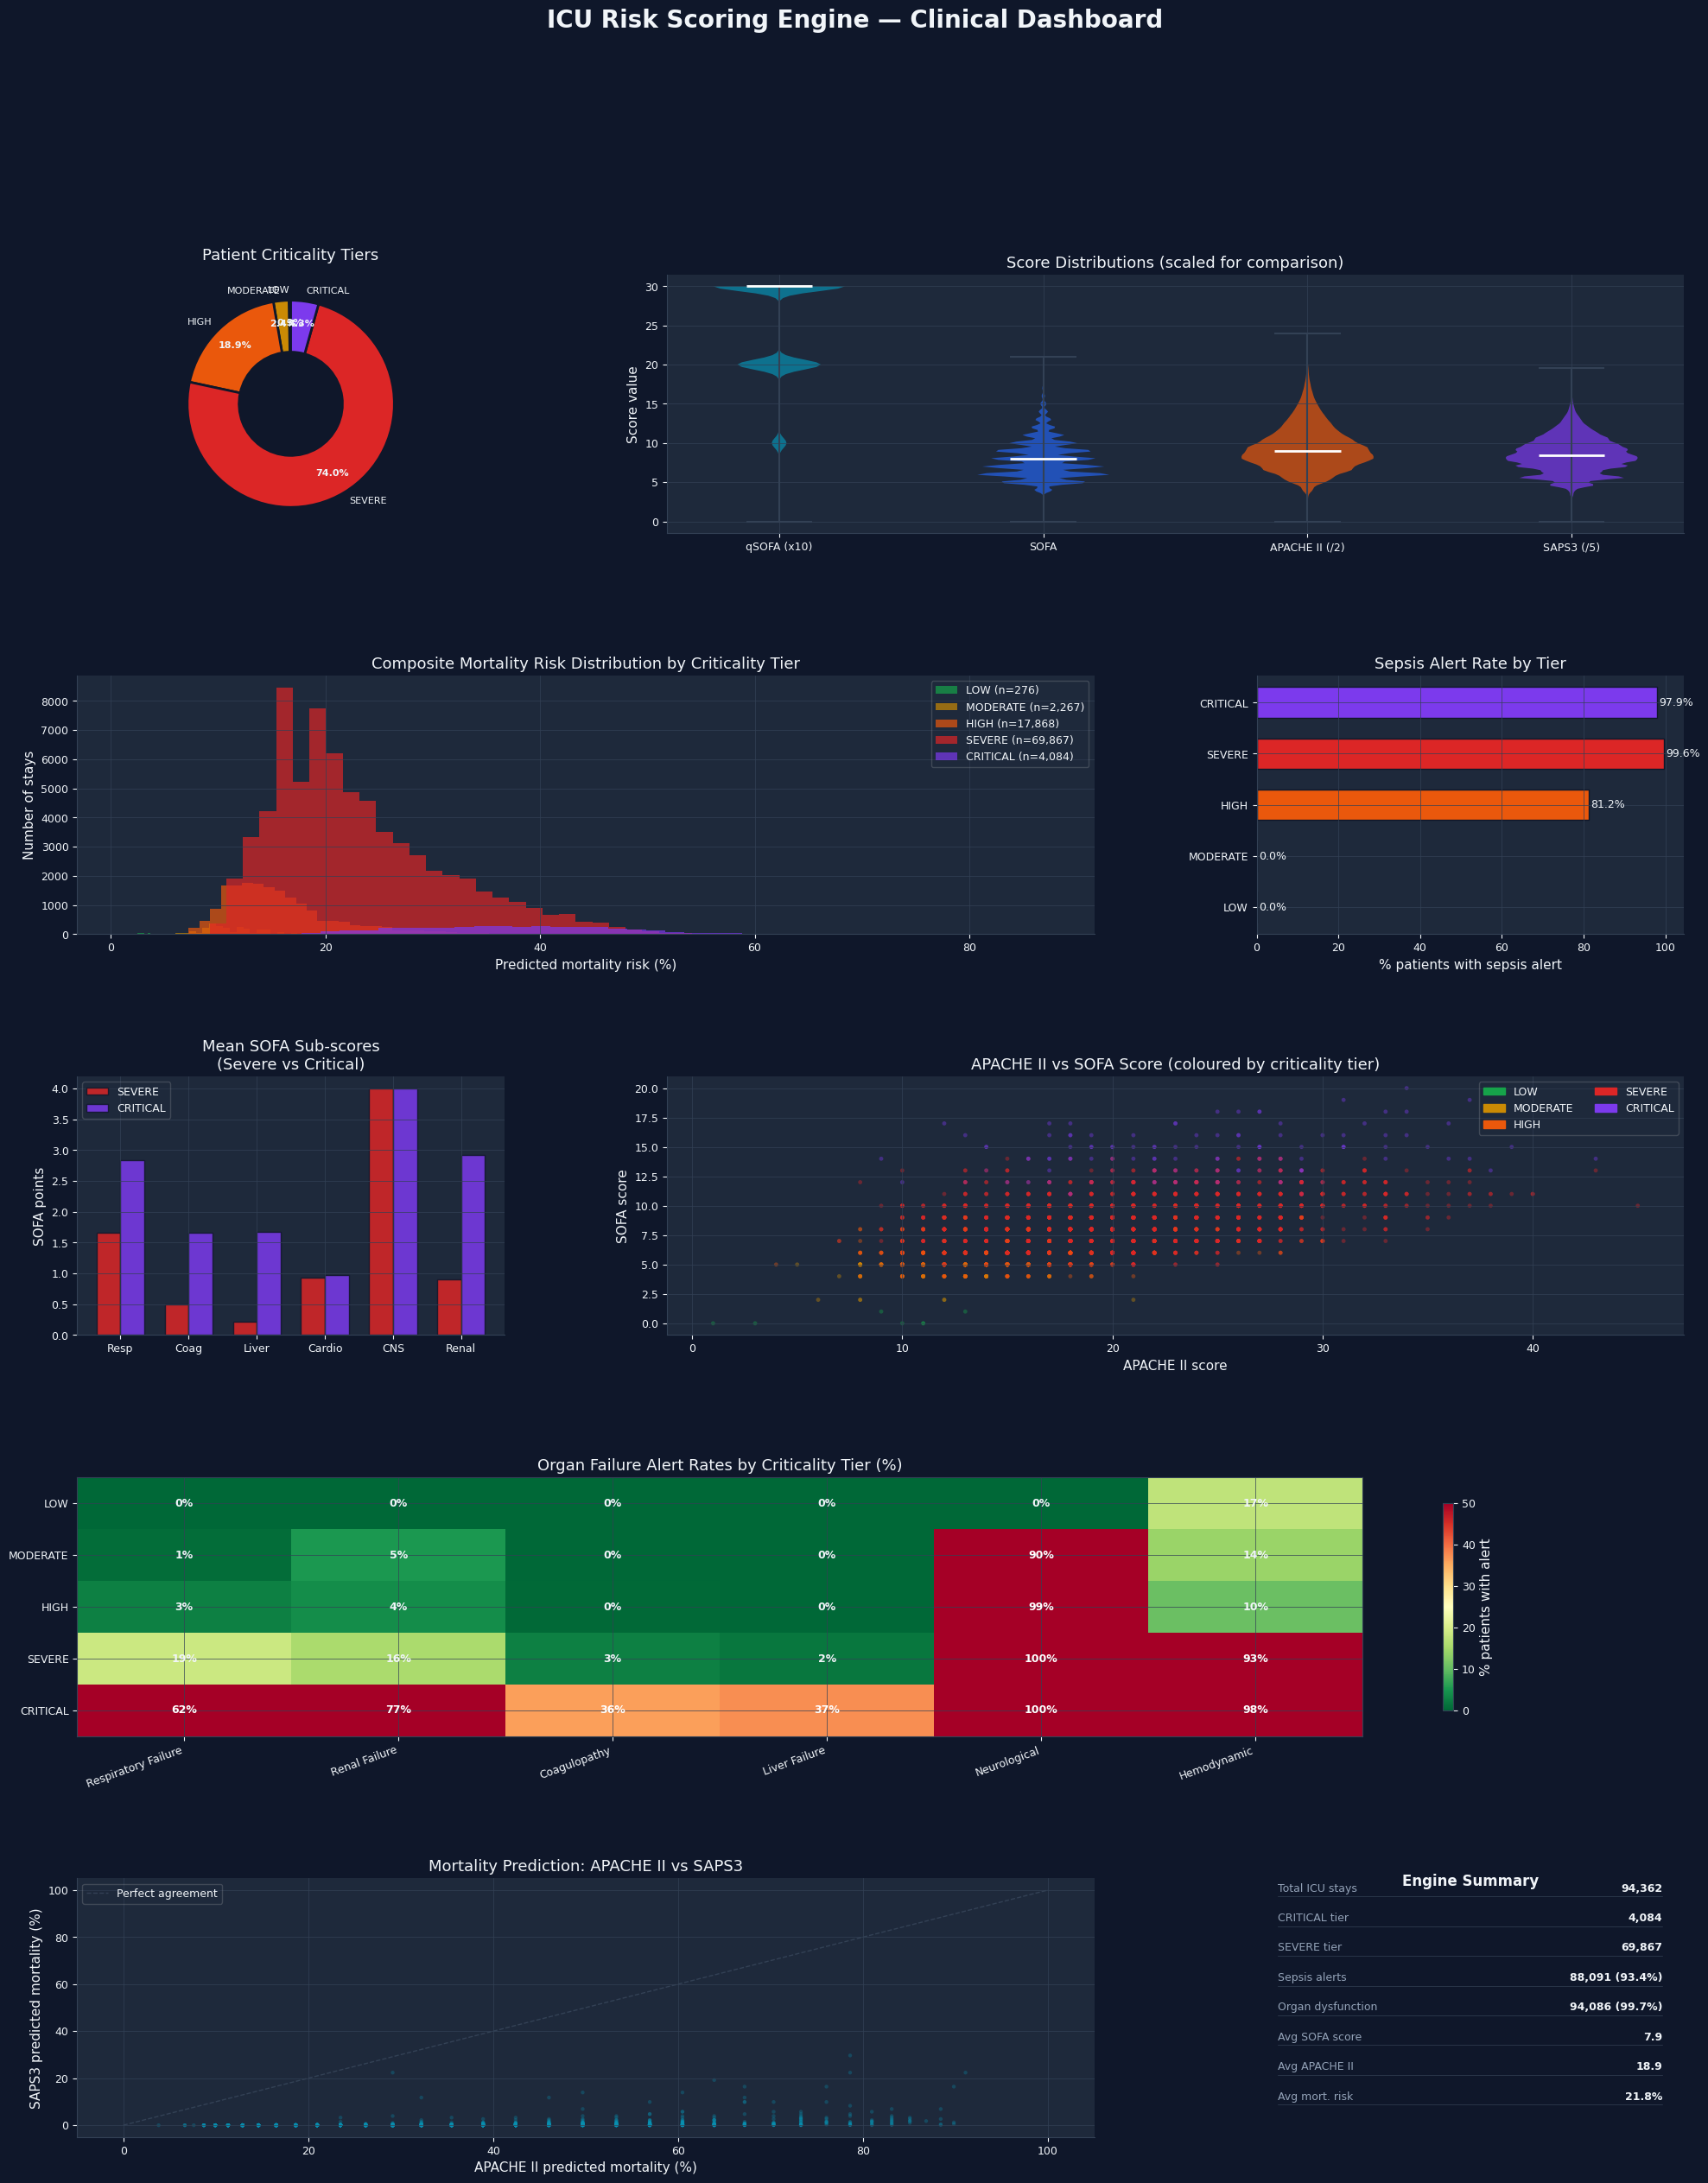

Dashboard saved.


In [9]:
TIER_COLORS = {
    'LOW':      '#16A34A',
    'MODERATE': '#CA8A04',
    'HIGH':     '#EA580C',
    'SEVERE':   '#DC2626',
    'CRITICAL': '#7C3AED',
}
TIER_ORDER = ['LOW', 'MODERATE', 'HIGH', 'SEVERE', 'CRITICAL']

def _spines_off(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig = plt.figure(figsize=(24, 28), facecolor=DARK_BG)
fig.suptitle('ICU Risk Scoring Engine — Clinical Dashboard',
             fontsize=20, fontweight='bold', color=TEXT_COLOR, y=0.99)
gs = gridspec.GridSpec(5, 3, figure=fig, hspace=0.55, wspace=0.38)


# ── 1. Criticality Tier Distribution (Donut)
ax1 = fig.add_subplot(gs[0, 0])
tier_counts = scores_df['criticality_tier'].value_counts().reindex(TIER_ORDER)
colors_tier = [TIER_COLORS[t] for t in TIER_ORDER]
wedges, texts, autotexts = ax1.pie(
    tier_counts, labels=TIER_ORDER,
    autopct='%1.1f%%', startangle=90,
    colors=colors_tier,
    wedgeprops=dict(width=0.5, edgecolor=DARK_BG, linewidth=2),
    pctdistance=0.78,
    textprops={'color': TEXT_COLOR, 'fontsize': 8},
)
for at in autotexts: at.set_fontweight('bold')
ax1.set_title('Patient Criticality Tiers', pad=12)


# ── 2. Score Distributions (Violin)
ax2 = fig.add_subplot(gs[0, 1:])
score_data = [
    scores_df['qsofa_score'].dropna() * 10,  # scale to compare
    scores_df['sofa_score'].dropna(),
    scores_df['apache2_score'].dropna() / 2,
    scores_df['saps3_score'].dropna() / 5,
]
vp = ax2.violinplot(score_data, positions=[1,2,3,4], showmedians=True)
colors_v = [PAL['teal'], PAL['blue'], PAL['orange'], PAL['purple']]
for body, c in zip(vp['bodies'], colors_v):
    body.set_facecolor(c); body.set_alpha(0.7)
vp['cmedians'].set_colors('white'); vp['cmedians'].set_linewidth(2)
for part in ('cbars','cmins','cmaxes'):
    vp[part].set_colors(GRID_COLOR)
ax2.set_xticks([1,2,3,4])
ax2.set_xticklabels(['qSOFA (x10)', 'SOFA', 'APACHE II (/2)', 'SAPS3 (/5)'])
ax2.set_title('Score Distributions (scaled for comparison)')
ax2.set_ylabel('Score value')
_spines_off(ax2)


# ── 3. Composite Mortality Risk by Tier
ax3 = fig.add_subplot(gs[1, :2])
for tier in TIER_ORDER:
    data = scores_df.loc[scores_df['criticality_tier']==tier, 'composite_mortality_risk'] * 100
    if len(data) < 5: continue
    ax3.hist(data, bins=40, alpha=0.7, color=TIER_COLORS[tier],
             label=f'{tier} (n={len(data):,})', edgecolor='none')
ax3.set_title('Composite Mortality Risk Distribution by Criticality Tier')
ax3.set_xlabel('Predicted mortality risk (%)')
ax3.set_ylabel('Number of stays')
ax3.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax3)


# ── 4. Sepsis Alert Breakdown
ax4 = fig.add_subplot(gs[1, 2])
sepsis_tbl = scores_df.groupby('criticality_tier')['sepsis_alert'].mean() * 100
sepsis_tbl = sepsis_tbl.reindex(TIER_ORDER)
bars = ax4.barh(TIER_ORDER, sepsis_tbl.values,
                color=[TIER_COLORS[t] for t in TIER_ORDER],
                edgecolor=DARK_BG, height=0.6)
for bar, val in zip(bars, sepsis_tbl.values):
    if not np.isnan(val):
        ax4.text(val+0.5, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, color=TEXT_COLOR)
ax4.set_title('Sepsis Alert Rate by Tier')
ax4.set_xlabel('% patients with sepsis alert')
_spines_off(ax4)


# ── 5. Organ Failure Radar (mean SOFA sub-scores by tier)
ax5 = fig.add_subplot(gs[2, 0])
sofa_subs = ['sofa_resp','sofa_coag','sofa_liver','sofa_cardio','sofa_cns','sofa_renal']
labels_radar = ['Resp','Coag','Liver','Cardio','CNS','Renal']
for tier in ['SEVERE','CRITICAL']:
    vals = scores_df.loc[scores_df['criticality_tier']==tier, sofa_subs].mean().values
    ax5.bar(np.arange(len(labels_radar)) + (0.35 if tier=='CRITICAL' else 0),
            vals, width=0.35, color=TIER_COLORS[tier], alpha=0.85,
            label=tier, edgecolor=DARK_BG)
ax5.set_xticks(np.arange(len(labels_radar)) + 0.175)
ax5.set_xticklabels(labels_radar)
ax5.set_title('Mean SOFA Sub-scores\n(Severe vs Critical)')
ax5.set_ylabel('SOFA points')
ax5.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax5)


# ── 6. APACHE II vs SOFA Scatter (sample 3000)
ax6 = fig.add_subplot(gs[2, 1:])
sample = scores_df.sample(min(3000, len(scores_df)), random_state=42)
tier_num = sample['criticality_tier'].map(
    {'LOW':0,'MODERATE':1,'HIGH':2,'SEVERE':3,'CRITICAL':4})
scatter = ax6.scatter(
    sample['apache2_score'], sample['sofa_score'],
    c=tier_num, cmap=LinearSegmentedColormap.from_list(
        'risk', list(TIER_COLORS.values())),
    alpha=0.4, s=12, edgecolors='none'
)
ax6.set_title('APACHE II vs SOFA Score (coloured by criticality tier)')
ax6.set_xlabel('APACHE II score')
ax6.set_ylabel('SOFA score')
legend_patches = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in TIER_ORDER]
ax6.legend(handles=legend_patches, framealpha=0.2, facecolor=CARD_BG, ncol=2)
_spines_off(ax6)


# ── 7. Alert Heatmap across tiers
ax7 = fig.add_subplot(gs[3, :])
alert_cols = [c for c in scores_df.columns if c.startswith('alert_')]
alert_labels = [c.replace('alert_','').replace('_',' ').title() for c in alert_cols]
heatmap_data = (
    scores_df.groupby('criticality_tier')[alert_cols].mean() * 100
).reindex(TIER_ORDER)
im = ax7.imshow(heatmap_data.values, aspect='auto', cmap='RdYlGn_r',
                vmin=0, vmax=50)
ax7.set_xticks(range(len(alert_labels)))
ax7.set_xticklabels(alert_labels, rotation=20, ha='right')
ax7.set_yticks(range(len(TIER_ORDER)))
ax7.set_yticklabels(TIER_ORDER)
for i in range(len(TIER_ORDER)):
    for j in range(len(alert_cols)):
        val = heatmap_data.values[i, j]
        ax7.text(j, i, f'{val:.0f}%', ha='center', va='center',
                 fontsize=9, color='white' if val > 25 else TEXT_COLOR,
                 fontweight='bold')
plt.colorbar(im, ax=ax7, label='% patients with alert', shrink=0.8)
ax7.set_title('Organ Failure Alert Rates by Criticality Tier (%)')


# ── 8. Mortality risk comparison: APACHE II vs SAPS3
ax8 = fig.add_subplot(gs[4, :2])
ax8.scatter(
    scores_df.sample(min(2000,len(scores_df)),random_state=1)['apache2_pred_mortality']*100,
    scores_df.sample(min(2000,len(scores_df)),random_state=1)['saps3_pred_mortality']*100,
    alpha=0.3, s=10, color=PAL['teal'], edgecolors='none'
)
ax8.plot([0,100],[0,100], '--', color=GRID_COLOR, lw=1, label='Perfect agreement')
ax8.set_title('Mortality Prediction: APACHE II vs SAPS3')
ax8.set_xlabel('APACHE II predicted mortality (%)')
ax8.set_ylabel('SAPS3 predicted mortality (%)')
ax8.legend(framealpha=0.2, facecolor=CARD_BG)
_spines_off(ax8)


# ── 9. Summary stats card
ax9 = fig.add_subplot(gs[4, 2])
ax9.axis('off')
stats = {
    'Total ICU stays':     f"{len(scores_df):,}",
    'CRITICAL tier':       f"{(scores_df['criticality_tier']=='CRITICAL').sum():,}",
    'SEVERE tier':         f"{(scores_df['criticality_tier']=='SEVERE').sum():,}",
    'Sepsis alerts':       f"{scores_df['sepsis_alert'].sum():,} ({scores_df['sepsis_alert'].mean()*100:.1f}%)",
    'Organ dysfunction':   f"{scores_df['organ_dysfunction'].sum():,} ({scores_df['organ_dysfunction'].mean()*100:.1f}%)",
    'Avg SOFA score':      f"{scores_df['sofa_score'].mean():.1f}",
    'Avg APACHE II':       f"{scores_df['apache2_score'].mean():.1f}",
    'Avg mort. risk':      f"{scores_df['composite_mortality_risk'].mean()*100:.1f}%",
}
y = 0.95
ax9.text(0.5, 1.02, 'Engine Summary', ha='center', va='top',
         fontsize=12, fontweight='bold', color=TEXT_COLOR, transform=ax9.transAxes)
for label, value in stats.items():
    ax9.text(0.05, y, label, fontsize=9, color='#94A3B8', transform=ax9.transAxes)
    ax9.text(0.95, y, value, fontsize=9, fontweight='bold',
             color=TEXT_COLOR, ha='right', transform=ax9.transAxes)
    ax9.plot([0.05, 0.95], [y-0.02, y-0.02], color=GRID_COLOR, lw=0.5,
             transform=ax9.transAxes)
    y -= 0.115

plt.savefig(
    '/content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/icu_risk_dashboard.png',
    dpi=180, bbox_inches='tight', facecolor=DARK_BG
)
plt.show()
print('Dashboard saved.')


## Step 10 — Physician Priority Table
> Top patients to review — sorted by criticality tier and composite mortality risk


In [10]:
priority_cols = [
    'stay_id', 'subject_id', 'age_icu', 'gender',
    'criticality_tier', 'priority_rank',
    'qsofa_score', 'sofa_score', 'apache2_score', 'saps3_score',
    'composite_mortality_risk', 'sepsis_alert', 'organ_failure_count',
    'alert_respiratory_failure', 'alert_renal_failure',
    'alert_coagulopathy', 'alert_hemodynamic',
]

priority_table = (
    scores_df[priority_cols]
    .sort_values(['priority_rank', 'composite_mortality_risk'], ascending=[True, False])
    .reset_index(drop=True)
)

print('=== TOP 20 PATIENTS TO PRIORITISE ===')
print(priority_table.head(20).to_string(index=False))


=== TOP 20 PATIENTS TO PRIORITISE ===
 stay_id  subject_id  age_icu gender criticality_tier  priority_rank  qsofa_score  sofa_score  apache2_score  saps3_score  composite_mortality_risk  sepsis_alert  organ_failure_count  alert_respiratory_failure  alert_renal_failure  alert_coagulopathy  alert_hemodynamic
35201523    10236942       64      M         CRITICAL              1            3          19             38           97                    0.8734             1                    5                          0                    1                   1                  1
31148413    10236280       74      M         CRITICAL              1            3          17             38           95                    0.8418             1                    5                          0                    1                   1                  1
34752926    12083759       77      M         CRITICAL              1            3          16             38           96                    0.8372     

## Step 11 — Save Risk Scores Parquet

In [11]:
# Select final output columns
score_output_cols = [
    'stay_id', 'subject_id', 'hadm_id', 'age_icu', 'gender',
    'is_elective', 'has_chronic',
    # qSOFA
    'qsofa_score', 'qsofa_risk', 'sepsis_screen_positive',
    # SOFA
    'sofa_score', 'sofa_resp', 'sofa_coag', 'sofa_liver',
    'sofa_cardio', 'sofa_cns', 'sofa_renal', 'sofa_risk', 'organ_dysfunction',
    # APACHE II
    'apache2_score', 'apache2_pred_mortality', 'apache2_risk',
    # SAPS3
    'saps3_score', 'saps3_pred_mortality', 'saps3_risk',
    # Engine outputs
    'composite_mortality_risk', 'sepsis_alert',
    'organ_failure_count', 'criticality_tier', 'priority_rank',
    # Alerts
    'alert_respiratory_failure', 'alert_renal_failure', 'alert_coagulopathy',
    'alert_liver_failure', 'alert_neurological', 'alert_hemodynamic',
]

final_scores = scores_df[score_output_cols].copy()
final_scores.to_parquet(SCORES_PATH, index=False, engine='pyarrow', compression='snappy')

size_mb = SCORES_PATH.stat().st_size / 1e6
print(f'Saved -> {SCORES_PATH}')
print(f'Shape  : {final_scores.shape}')
print(f'Size   : {size_mb:.1f} MB')
print(f'Columns: {list(final_scores.columns)}')


Saved -> /content/drive/MyDrive/Multimoal_ICUAIAssistant_Claud/Parquet/icu_risk_scores.parquet
Shape  : (94362, 36)
Size   : 2.9 MB
Columns: ['stay_id', 'subject_id', 'hadm_id', 'age_icu', 'gender', 'is_elective', 'has_chronic', 'qsofa_score', 'qsofa_risk', 'sepsis_screen_positive', 'sofa_score', 'sofa_resp', 'sofa_coag', 'sofa_liver', 'sofa_cardio', 'sofa_cns', 'sofa_renal', 'sofa_risk', 'organ_dysfunction', 'apache2_score', 'apache2_pred_mortality', 'apache2_risk', 'saps3_score', 'saps3_pred_mortality', 'saps3_risk', 'composite_mortality_risk', 'sepsis_alert', 'organ_failure_count', 'criticality_tier', 'priority_rank', 'alert_respiratory_failure', 'alert_renal_failure', 'alert_coagulopathy', 'alert_liver_failure', 'alert_neurological', 'alert_hemodynamic']
